In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Eigene robusten Parquet-Helper
from utils.parquet_io import load_parquet

# Projekt-Root bestimmen (2 Ebenen über notebooks/)
ROOT = Path.cwd().parents[0]   # oder ggf. .parents[1], je nachdem wo dein notebooks/ liegt
DATA_DIR = ROOT / "data"

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
def load_and_info(path: Path) -> pd.DataFrame:
    """Lädt ein Parquet und gibt Infos aus."""
    df = load_parquet(path)
    print(f"\n--- {path.name} ---")
    print(f"Shape: {df.shape}")
    print(f"Columns: {len(df.columns)}")
    return df

ROOT: C:\Dev\Bachelorarbeit
DATA_DIR: C:\Dev\Bachelorarbeit\data


In [29]:
raw_dir = DATA_DIR / "raw" / "assets_regions"

df_btc = load_and_info(raw_dir / "BTC-USD.parquet")
display(df_btc.head(), df_btc.tail())

df_spy = load_and_info(raw_dir / "SPY.parquet")
display(df_spy.head(), df_spy.tail())


--- BTC-USD.parquet ---
Shape: (3865, 8)
Columns: 8


,date,open,high,low,close,volume,volumeNotional,tradesDone
0,2014-06-01T00:00:00+00:00,621.00,628.50,611.00,627.80,9696.71,6.087595e+06,0.0
1,2014-06-02T00:00:00+00:00,627.80,683.26,618.53,630.99,24149.98,1.523840e+07,0.0
2,2014-06-03T00:00:00+00:00,630.99,678.00,613.03,661.22,20087.28,1.328211e+07,0.0
3,2014-06-04T00:00:00+00:00,662.00,680.99,649.61,670.14,13572.81,9.095683e+06,0.0
4,2014-06-05T00:00:00+00:00,668.90,673.61,621.86,640.59,17375.57,1.113062e+07,0.0


,date,open,high,low,close,volume,volumeNotional,tradesDone
3860,2024-12-28T00:00:00+00:00,94185.035310,95557.388043,94030.431040,95163.632624,4248.139276,4.042684e+08,454540.0
3861,2024-12-29T00:00:00+00:00,95172.839996,95206.884230,92884.741082,93603.088025,5410.327008,5.064233e+08,457803.0
3862,2024-12-30T00:00:00+00:00,93596.204244,94926.586665,91312.413450,92656.240425,20819.468761,1.929054e+09,774207.0
3863,2024-12-31T00:00:00+00:00,92650.418961,96161.032971,91911.081744,93390.555466,14572.349802,1.360920e+09,688046.0
3864,2025-01-01T00:00:00+00:00,93376.269836,94977.830995,92765.302188,94407.764230,8931.655782,8.432177e+08,457051.0



--- SPY.parquet ---
Shape: (2665, 13)
Columns: 13


,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,2014-06-02T00:00:00.000Z,192.90,192.99,191.97,192.95,64655648,158.575794,158.649779,157.811276,158.616897,64655648,0.0,1.0
1,2014-06-03T00:00:00.000Z,192.80,192.90,192.25,192.43,65047193,158.493587,158.575794,158.041453,158.189424,65047193,0.0,1.0
2,2014-06-04T00:00:00.000Z,193.19,193.30,192.27,192.47,55529372,158.814192,158.904619,158.057895,158.222307,55529372,0.0,1.0
3,2014-06-05T00:00:00.000Z,194.45,194.65,192.70,193.41,92102592,159.849990,160.014403,158.411381,158.995045,92102592,0.0,1.0
4,2014-06-06T00:00:00.000Z,195.38,195.43,194.78,194.87,78696219,160.614508,160.655611,160.121271,160.195256,78696219,0.0,1.0


,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
2660,2024-12-24T00:00:00.000Z,601.30,601.3400,595.4700,596.060,33160097,597.726363,597.766125,591.931012,592.517505,33160097,0.0,1.0
2661,2024-12-26T00:00:00.000Z,601.34,602.4800,598.0825,599.500,41338891,597.766125,598.899350,594.527985,595.937061,41338891,0.0,1.0
2662,2024-12-27T00:00:00.000Z,595.01,597.7761,590.7647,597.540,64969310,591.473745,594.223406,587.253676,593.988709,64969310,0.0,1.0
2663,2024-12-30T00:00:00.000Z,588.22,591.7400,584.4100,587.890,56578757,584.724100,588.223180,580.936743,584.396061,56578757,0.0,1.0
2664,2024-12-31T00:00:00.000Z,586.08,590.6399,584.4200,589.905,57052654,582.596818,587.129618,580.946684,586.399085,57052654,0.0,1.0


In [22]:
df_interim = load_and_info(DATA_DIR / "interim" / "panel.parquet")
display(df_interim.head(), df_interim.tail())

# Beispiel: alle Spalten
print(df_interim.columns.tolist()[:10], "...")

# Nach Datum & Asset filtern
sample_date = str(df_interim.index.get_level_values("date")[0].date())
df_interim_date = df_interim.xs("BTC-USD", level="asset").loc["2015-01-01":"2015-01-21"]
display(df_interim_date)



--- panel.parquet ---
Shape: (21320, 8)
Columns: 8


open    high     low   close   adj_close  \
date                      asset                                                 
2014-06-02 00:00:00+00:00 BTC-USD  627.80  683.26  618.53  630.99  630.990000   
                          ETH-USD     NaN     NaN     NaN     NaN         NaN   
                          EWC       30.78   30.78   30.60   30.67   24.023526   
                          EWJ       11.72   11.75   11.66   11.72   38.750370   
                          IAU       12.07   12.12   12.04   12.04   24.080000   

                                        volume  dividends  stock_splits  
date                      asset                                          
2014-06-02 00:00:00+00:00 BTC-USD     24149.98        0.0           1.0  
                          ETH-USD          NaN        NaN           NaN  
                          EWC       1413800.00        0.0           1.0  
                          EWJ      40968900.00        0.0           1.0  
                          IAU       1826700.00        0.0           1.0

open      high       low   close  \
date                      asset                                        
2024-12-31 00:00:00+00:00 EWJ     67.020   67.4900   66.9900   67.10   
                          IAU     49.300   49.6000   49.3000   49.51   
                          IEMG    52.340   52.4399   52.1244   52.22   
                          IEUR    54.370   54.3800   53.8900   53.98   
                          SPY    589.905  590.6399  584.4200  586.08   

                                  adj_close      volume  dividends  \
date                      asset                                      
2024-12-31 00:00:00+00:00 EWJ     66.562067   2758969.0        0.0   
                          IAU     49.510000   3248798.0        0.0   
                          IEMG    51.595796   8112635.0        0.0   
                          IEUR    52.956099   1591024.0        0.0   
                          SPY    582.596818  57052654.0        0.0   

                                 stock_splits  
date                      asset                
2024-12-31 00:00:00+00:00 EWJ             1.0  
                          IAU             1.0  
                          IEMG            1.0  
                          IEUR            1.0  
                          SPY             1.0

['open', 'high', 'low', 'close', 'adj_close', 'volume', 'dividends', 'stock_splits'] ...


,open,high,low,close,adj_close,volume,dividends,stock_splits
date,,,,,,,,
2015-01-02 00:00:00+00:00,321.00,321.00,312.60,313.81,313.81,3087.44,0.0,1.0
2015-01-05 00:00:00+00:00,280.00,289.39,255.00,264.00,264.00,41441.28,0.0,1.0
2015-01-06 00:00:00+00:00,264.55,280.00,264.07,276.80,276.80,9528.27,0.0,1.0
2015-01-07 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-08 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-09 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-12 00:00:00+00:00,275.60,280.94,262.08,266.39,266.39,12758.95,0.0,1.0
2015-01-13 00:00:00+00:00,266.34,272.43,263.54,267.42,267.42,10478.25,0.0,1.0
2015-01-14 00:00:00+00:00,267.10,268.15,216.00,227.00,227.00,60556.16,0.0,1.0



--- features_v1.parquet ---
Shape: (21320, 29)
Columns: 29


open        high         low  \
date                      asset                                         
2014-06-02 00:00:00+00:00 BTC-USD  627.799988  683.260010  618.530029   
                          ETH-USD         NaN         NaN         NaN   
                          EWC       30.780001   30.780001   30.600000   
                          EWJ       11.720000   11.750000   11.660000   
                          IAU       12.070000   12.120000   12.040000   
                          IEMG      51.110001   51.189999   51.020000   
                          IEUR            NaN         NaN         NaN   
                          SPY      192.949997  192.990005  191.970001   
2014-06-03 00:00:00+00:00 BTC-USD  630.989990  678.000000  613.030029   

                                        close   adj_close        volume  \
date                      asset                                           
2014-06-02 00:00:00+00:00 BTC-USD  630.989990  630.989990  2.414998e+04   
                          ETH-USD         NaN         NaN           NaN   
                          EWC       30.670000   24.023525  1.413800e+06   
                          EWJ       11.720000   38.750370  4.096890e+07   
                          IAU       12.040000   24.080000  1.826700e+06   
                          IEMG      51.099998   37.807644  1.074000e+06   
                          IEUR            NaN         NaN           NaN   
                          SPY      192.899994  158.575790  6.465565e+07   
2014-06-03 00:00:00+00:00 BTC-USD  661.219971  661.219971  2.008728e+04   

                                   dividends  stock_splits  daily_return_log  \
date                      asset                                                
2014-06-02 00:00:00+00:00 BTC-USD        0.0           1.0               NaN   
                          ETH-USD        NaN           NaN               NaN   
                          EWC            0.0           1.0               NaN   
                          EWJ            0.0           1.0               NaN   
                          IAU            0.0           1.0               NaN   
                          IEMG           0.0           1.0               NaN   
                          IEUR           NaN           NaN               NaN   
                          SPY            0.0           1.0               NaN   
2014-06-03 00:00:00+00:00 BTC-USD        0.0           1.0          0.046797   

                                   average_dollar_volume_20  ...  \
date                      asset                              ...   
2014-06-02 00:00:00+00:00 BTC-USD                       NaN  ...   
                          ETH-USD                       NaN  ...   
                          EWC                           NaN  ...   
                          EWJ                           NaN  ...   
                          IAU                           NaN  ...   
                          IEMG                          NaN  ...   
                          IEUR                          NaN  ...   
                          SPY                           NaN  ...   
2014-06-03 00:00:00+00:00 BTC-USD                       NaN  ...   

                                   macd_histogram_12_26_9  \
date                      asset                             
2014-06-02 00:00:00+00:00 BTC-USD                0.000000   
                          ETH-USD                     NaN   
                          EWC                    0.000000   
                          EWJ                    0.000000   
                          IAU                    0.000000   
                          IEMG                   0.000000   
                          IEUR                        NaN   
                          SPY                    0.000000   
2014-06-03 00:00:00+00:00 BTC-USD                1.929208   

                                   bollinger_middle_band_20_2.0  \
date                      asset           

open          high           low  \
date                      asset                                               
2024-12-27 00:00:00+00:00 IAU         49.360001     49.485500     49.299999   
                          IEMG        52.650002     52.759998     52.485001   
                          IEUR        54.270000     54.509998     54.189999   
                          SPY        597.539978    597.776123    590.764709   
2024-12-30 00:00:00+00:00 BTC-USD  93596.203125  94926.585938  91312.414062   
                          ETH-USD   3352.259033   3431.808594   3296.872803   
                          EWC         40.110001     40.259998     39.737499   
                          EWJ         67.110001     67.400002     66.904999   
                          IAU         49.299999     49.299999     49.000000   
                          IEMG        52.450001     52.540001     52.195000   
                          IEUR        54.080002     54.209999     53.770000   
                          SPY        587.890015    591.739990    584.409973   
2024-12-31 00:00:00+00:00 BTC-USD  92650.421875  96161.031250  91911.078125   
                          ETH-USD   3356.422852   3447.559082   3311.252441   
                          EWC         40.099998     40.317402     40.060001   
                          EWJ         67.019997     67.489998     66.989998   
                          IAU         49.299999     49.599998     49.299999   
                          IEMG        52.340000     52.439899     52.124401   
                          IEUR        54.369999     54.380001     53.889999   
                          SPY        589.905029    590.639893    584.419983   

                                          close     adj_close        volume  \
date                      asset                                               
2024-12-27 00:00:00+00:00 IAU         49.369999     49.369999  2.654274e+06   
                          IEMG        52.740002     52.109581  6.751850e+06   
                          IEUR        54.419998     53.387753  9.028010e+05   
                          SPY        595.010010    591.473755  6.496931e+07   
2024-12-30 00:00:00+00:00 BTC-USD  92656.242188  92656.242188  2.081947e+04   
                          ETH-USD   3358.908447   3358.908447  1.648088e+05   
                          EWC         40.090000     39.823753  1.126805e+06   
                          EWJ         67.160004     66.621582  3.564864e+06   
                          IAU         49.220001     49.220001  2.625002e+06   
                          IEMG        52.310001     51.684719  1.159275e+07   
                          IEUR        54.029999     53.005150  6.204310e+05   
                          SPY        588.219971    584.724121  5.657876e+07   
2024-12-31 00:00:00+00:00 BTC-USD  93390.554688  93390.554688  1.457235e+04   
                          ETH-USD   3332.065918   3332.065918  1.229592e+05   
                          EWC         40.299999     40.032360  3.154640e+06   
                          EWJ         67.099998     66.562065  2.758969e+06   
                          IAU         49.509998     49.509998  3.248798e+06   
                          IEMG        52.220001     51.595795  8.112635e+06   
                          IEUR        53.980000     52.956100  1.591024e+06   
                          SPY        586.080017    582.596802  5.705266e+07   

                                   dividends  stock_splits  daily_return_log  \
date                      asset                                                
2024-12-27 00:00:00+00:00 IAU            0.0           1.0         -0.007064   
                          IEMG           0.0           1.0         -0.003974   
                          IEUR           0.0           1.0         -0.003119   
                          SPY            0.0           1.0         -0.010582   
2024-12-30 00:00:00+00:00 BTC-USD        0.0           1.0         -0.016275   
     

['open', 'high', 'low', 'close', 'adj_close', 'volume', 'dividends', 'stock_splits', 'daily_return_log', 'average_dollar_volume_20', 'volatility_becker_parkinson', 'bid_ask_spread_corwin_schultz', 'simple_moving_average_20', 'simple_moving_average_60', 'exponential_moving_average_12'] ...


,open,high,low,close,adj_close,volume,dividends,stock_splits,daily_return_log,average_dollar_volume_20,...,macd_histogram_12_26_9,bollinger_middle_band_20_2.0,bollinger_upper_band_20_2.0,bollinger_lower_band_20_2.0,bollinger_bandwidth_20_2.0,commodity_channel_index_20,average_directional_index_14,positive_directional_index_14,negative_directional_index_14,is_cash
date,,,,,,,,,,,,,,,,,,,,,
2015-01-02 00:00:00+00:00,28.620001,28.820000,28.530001,28.690001,22.951942,2421612.0,0.0,1.0,-0.005908,53046008.0,...,0.130868,28.420000,29.627443,27.212557,0.084971,35.146835,29.474703,16.764502,27.450848,0
2015-01-05 00:00:00+00:00,28.420000,28.540001,27.770000,27.920000,22.335945,3434438.0,0.0,1.0,-0.027205,55523708.0,...,0.068606,28.343000,29.469004,27.216997,0.079455,-38.331879,30.331770,14.473908,34.987259,0
2015-01-06 00:00:00+00:00,27.910000,27.910000,27.350000,27.510000,22.007946,1992749.0,0.0,1.0,-0.014794,55794788.0,...,0.002605,28.254499,29.349827,27.159174,0.077533,-96.234222,31.627489,13.264635,38.220333,0
2015-01-07 00:00:00+00:00,27.620001,27.850000,27.459999,27.540001,22.031944,2172155.0,0.0,1.0,0.001090,56739180.0,...,-0.034206,28.206499,29.338123,27.074877,0.080238,-82.636383,32.830654,12.495393,36.003860,0
2015-01-08 00:00:00+00:00,27.730000,28.014999,27.730000,27.879999,22.303944,1524771.0,0.0,1.0,0.012270,56974096.0,...,-0.030930,28.167500,29.287622,27.047377,0.079533,-42.211510,33.399963,14.067587,33.458836,0


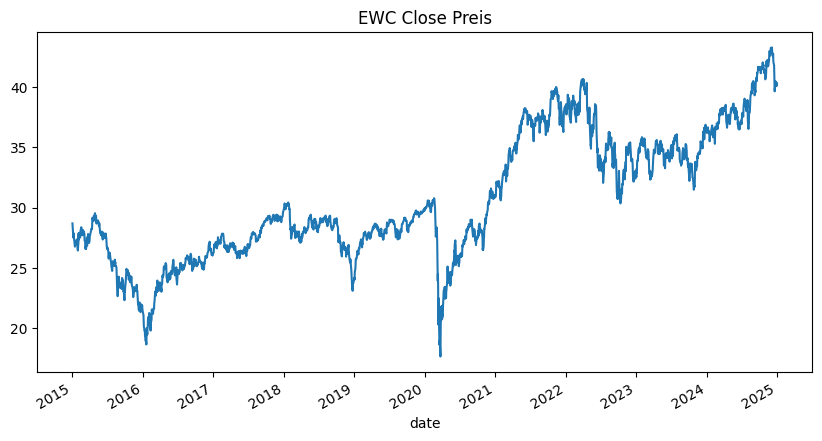

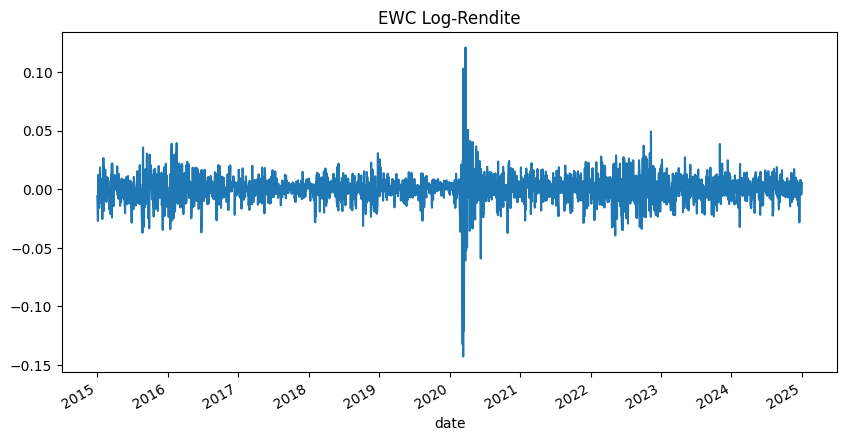

In [7]:
df_clean = load_and_info(DATA_DIR / "clean" / "features_v1.parquet")
display(df_clean.head(9), df_clean.tail(20))
# Spaltenliste
print(df_clean.columns.tolist()[:15], "...")

# Ein Asset über Zeitraum herausfiltern
asset = "EWC"
date_range = slice("2015-01-01", "2025-01-15")
df_clean_asset = df_clean.xs(asset, level="asset").loc[date_range]
display(df_clean_asset.head())

# Plot Close Preis
df_clean_asset["close"].plot(title=f"{asset} Close Preis", figsize=(10,5))
plt.show()

# Plot Log-Renditen
df_clean_asset["daily_return_log"].plot(title=f"{asset} Log-Rendite", figsize=(10,5))
plt.show()


In [44]:
df_rf = load_and_info(DATA_DIR / "clean" / "riskfree.parquet")
display(df_rf.head(), df_rf.tail())


--- riskfree.parquet ---
Shape: (2665, 1)
Columns: 1


,risk_free_annual
date,
2014-06-02 00:00:00+00:00,0.0009
2014-06-03 00:00:00+00:00,0.0010
2014-06-04 00:00:00+00:00,0.0009
2014-06-05 00:00:00+00:00,0.0009
2014-06-06 00:00:00+00:00,0.0009


,risk_free_annual
date,
2024-12-24 00:00:00+00:00,0.0433
2024-12-26 00:00:00+00:00,0.0433
2024-12-27 00:00:00+00:00,0.0433
2024-12-30 00:00:00+00:00,0.0433
2024-12-31 00:00:00+00:00,0.0433



--- portfolio_snapshots.parquet ---
Shape: (80, 10)
Columns: 10


,round,t,t_plus_1,asset,p_close_t1,shares,weight_post_t1,cash,portfolio_value_t1,fees_total_round
0,1,2015-01-02 00:00:00+00:00,2015-01-05 00:00:00+00:00,BTC-USD,264.000000,0.0,0.000000,26.595268,785693.465195,299.902051
1,1,2015-01-02 00:00:00+00:00,2015-01-05 00:00:00+00:00,ETH-USD,NaN,0.0,NaN,26.595268,785693.465195,299.902051
2,1,2015-01-02 00:00:00+00:00,2015-01-05 00:00:00+00:00,EWC,22.335945,35175.0,0.999966,26.595268,785693.465195,299.902051
3,1,2015-01-02 00:00:00+00:00,2015-01-05 00:00:00+00:00,EWJ,37.269531,0.0,0.000000,26.595268,785693.465195,299.902051
4,1,2015-01-02 00:00:00+00:00,2015-01-05 00:00:00+00:00,IAU,23.360001,0.0,0.000000,26.595268,785693.465195,299.902051
5,1,2015-01-02 00:00:00+00:00,2015-01-05 00:00:00+00:00,IEMG,34.714687,0.0,0.000000,26.595268,785693.465195,299.902051
6,1,2015-01-02 00:00:00+00:00,2015-01-05 00:00:00+00:00,IEUR,30.632603,0.0,0.000000,26.595268,785693.465195,299.902051
7,1,2015-01-02 00:00:00+00:00,2015-01-05 00:00:00+00:00,SPY,168.318756,0.0,0.000000,26.595268,785693.465195,299.902051
8,2,2015-01-05 00:00:00+00:00,2015-01-06 00:00:00+00:00,BTC-USD,276.799988,0.0,0.000000,981466.352343,981466.352343,294.520273
9,2,2015-01-05 00:00:00+00:00,2015-01-06 00:00:00+00:00,ETH-USD,NaN,0.0,NaN,981466.352343,981466.352343,294.520273


,round,t,t_plus_1,asset,p_close_t1,shares,weight_post_t1,cash,portfolio_value_t1,fees_total_round
60,8,2015-01-13 00:00:00+00:00,2015-01-14 00:00:00+00:00,IAU,23.760000,0.0,0.000000,940711.942491,940711.942491,282.293907
61,8,2015-01-13 00:00:00+00:00,2015-01-14 00:00:00+00:00,IEMG,35.615089,0.0,0.000000,940711.942491,940711.942491,282.293907
62,8,2015-01-13 00:00:00+00:00,2015-01-14 00:00:00+00:00,IEUR,30.922958,0.0,0.000000,940711.942491,940711.942491,282.293907
63,8,2015-01-13 00:00:00+00:00,2015-01-14 00:00:00+00:00,SPY,167.601151,0.0,0.000000,940711.942491,940711.942491,282.293907
64,9,2015-01-14 00:00:00+00:00,2015-01-15 00:00:00+00:00,BTC-USD,171.410004,0.0,0.000000,9.267855,740445.949431,282.126165
65,9,2015-01-14 00:00:00+00:00,2015-01-15 00:00:00+00:00,ETH-USD,NaN,0.0,NaN,9.267855,740445.949431,282.126165
66,9,2015-01-14 00:00:00+00:00,2015-01-15 00:00:00+00:00,EWC,21.407948,34587.0,0.999987,9.267855,740445.949431,282.126165
67,9,2015-01-14 00:00:00+00:00,2015-01-15 00:00:00+00:00,EWJ,37.637871,0.0,0.000000,9.267855,740445.949431,282.126165
68,9,2015-01-14 00:00:00+00:00,2015-01-15 00:00:00+00:00,IAU,24.360001,0.0,0.000000,9.267855,740445.949431,282.126165
69,9,2015-01-14 00:00:00+00:00,2015-01-15 00:00:00+00:00,IEMG,35.637787,0.0,0.000000,9.267855,740445.949431,282.126165



--- trade_events.parquet ---
Shape: (10, 12)
Columns: 12


,asset,q,p_ref,p_exec,notional_abs,spread_cost,fees,vol_slip,total_cost,round,t,t_plus_1
0,EWC,35175.0,28.420000,28.420000,999673.502684,0.00000,299.902051,0.0,299.902051,1,2015-01-02 00:00:00+00:00,2015-01-05 00:00:00+00:00
1,EWC,-35175.0,27.910000,27.910000,981734.244633,0.00000,294.520273,0.0,294.520273,2,2015-01-05 00:00:00+00:00,2015-01-06 00:00:00+00:00
2,EWC,35335.0,27.620001,27.767480,981163.899724,5211.17007,294.349170,0.0,294.349170,3,2015-01-06 00:00:00+00:00,2015-01-07 00:00:00+00:00
3,EWC,-35335.0,27.730000,27.730000,979839.533825,0.00000,293.951860,0.0,293.951860,4,2015-01-07 00:00:00+00:00,2015-01-08 00:00:00+00:00
4,EWC,35136.0,27.870001,27.870001,979240.349487,0.00000,293.772105,0.0,293.772105,5,2015-01-08 00:00:00+00:00,2015-01-09 00:00:00+00:00


,asset,q,p_ref,p_exec,notional_abs,spread_cost,fees,vol_slip,total_cost,round,t,t_plus_1
5,EWC,-35136.0,27.420000,27.420000,963429.122681,0.000000,289.028737,0.0,289.028737,6,2015-01-09 00:00:00+00:00,2015-01-12 00:00:00+00:00
6,EWC,35085.0,27.299999,27.443535,962856.414063,5035.940830,288.856924,0.0,288.856924,7,2015-01-12 00:00:00+00:00,2015-01-13 00:00:00+00:00
7,EWC,-35085.0,26.820000,26.820000,940979.689293,0.000000,282.293907,0.0,282.293907,8,2015-01-13 00:00:00+00:00,2015-01-14 00:00:00+00:00
8,EWC,34587.0,27.190001,27.190001,940420.548471,0.000000,282.126165,0.0,282.126165,9,2015-01-14 00:00:00+00:00,2015-01-15 00:00:00+00:00
9,EWC,-34587.0,26.610001,26.454395,914978.166175,5381.924935,274.493450,0.0,274.493450,10,2015-01-15 00:00:00+00:00,2015-01-16 00:00:00+00:00



--- rewards_log.parquet ---
Shape: (9, 17)
Columns: 17


,round,t,t_plus_1,nav_t1,nav_t,r_log_t,icvar_t,delta_mdd_t,reward_t,reward_kind,icvar_mode,alpha,window,lambda_,gamma,estimator,ewm_alpha
index,,,,,,,,,,,,,,,,,
1,2,2015-01-05 00:00:00+00:00,2015-01-06 00:00:00+00:00,981466.352343,785693.465195,0.222481,0.0,0.0,0.222481,log,ex_ante,0.05,252,1.0,1.0,rolling,0.1
2,3,2015-01-06 00:00:00+00:00,2015-01-07 00:00:00+00:00,778506.854403,981466.352343,-0.231670,0.0,0.0,-0.231670,log,ex_ante,0.05,252,1.0,1.0,rolling,0.1
3,4,2015-01-07 00:00:00+00:00,2015-01-08 00:00:00+00:00,979553.718066,778506.854403,0.229719,0.0,0.0,0.229719,log,ex_ante,0.05,252,1.0,1.0,rolling,0.1
4,5,2015-01-08 00:00:00+00:00,2015-01-09 00:00:00+00:00,776944.867837,979553.718066,-0.231728,0.0,0.0,-0.231728,log,ex_ante,0.05,252,1.0,1.0,rolling,0.1
5,6,2015-01-09 00:00:00+00:00,2015-01-12 00:00:00+00:00,963159.786734,776944.867837,0.214850,0.0,0.0,0.214850,log,ex_ante,0.05,252,1.0,1.0,rolling,0.1


,round,t,t_plus_1,nav_t1,nav_t,r_log_t,icvar_t,delta_mdd_t,reward_t,reward_kind,icvar_mode,alpha,window,lambda_,gamma,estimator,ewm_alpha
index,,,,,,,,,,,,,,,,,
5,6,2015-01-09 00:00:00+00:00,2015-01-12 00:00:00+00:00,963159.786734,776944.867837,0.214850,0.0,0.0,0.214850,log,ex_ante,0.05,252,1.0,1.0,rolling,0.1
6,7,2015-01-12 00:00:00+00:00,2015-01-13 00:00:00+00:00,760094.066481,963159.786734,-0.236777,0.0,0.0,-0.236777,log,ex_ante,0.05,252,1.0,1.0,rolling,0.1
7,8,2015-01-13 00:00:00+00:00,2015-01-14 00:00:00+00:00,940711.942491,760094.066481,0.213195,0.0,0.0,0.213195,log,ex_ante,0.05,252,1.0,1.0,rolling,0.1
8,9,2015-01-14 00:00:00+00:00,2015-01-15 00:00:00+00:00,740445.949431,940711.942491,-0.239384,0.0,0.0,-0.239384,log,ex_ante,0.05,252,1.0,1.0,rolling,0.1
9,10,2015-01-15 00:00:00+00:00,2015-01-16 00:00:00+00:00,914712.971071,740445.949431,0.211358,0.0,0.0,0.211358,log,ex_ante,0.05,252,1.0,1.0,rolling,0.1


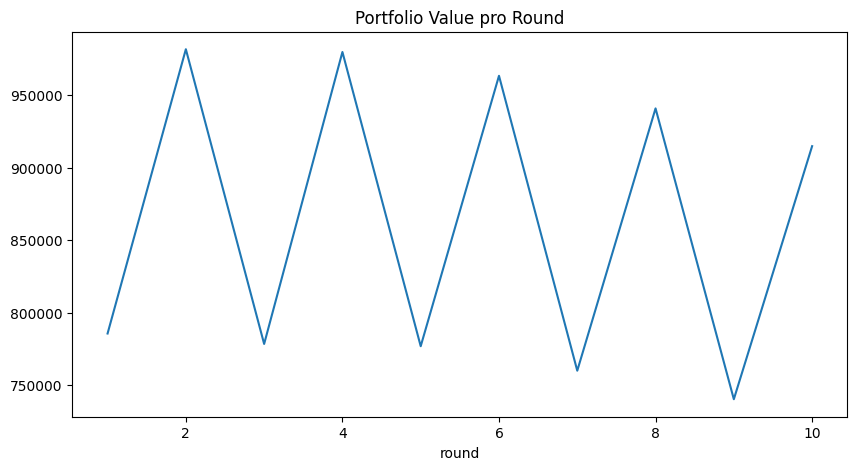

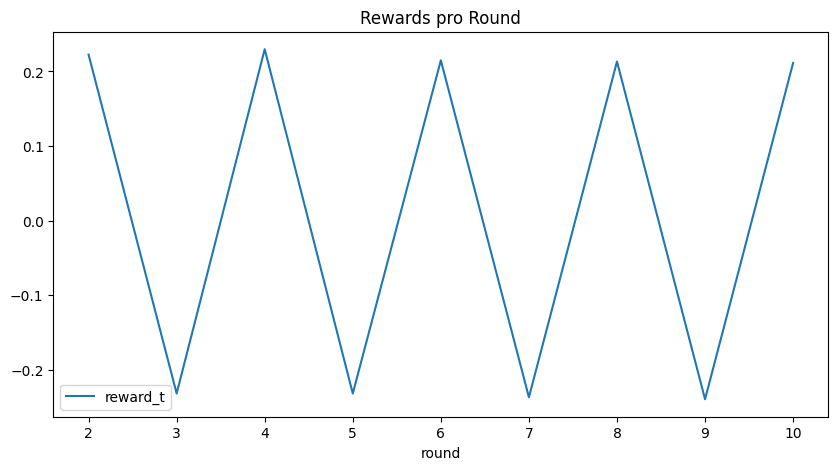

In [4]:
acc_demo = DATA_DIR / "accounting_demo"

df_snap = load_and_info(acc_demo / "portfolio_snapshots.parquet")
display(df_snap.head(20), df_snap.tail(20))

df_trades = load_and_info(acc_demo / "trade_events.parquet")
display(df_trades.head(), df_trades.tail())

df_rewards = load_and_info(acc_demo / "rewards_log.parquet")
display(df_rewards.head(), df_rewards.tail())

# Plot Portfolio Value Verlauf
df_snap.groupby("round")["portfolio_value_t1"].mean().plot(
    title="Portfolio Value pro Round", figsize=(10,5))
plt.show()

# Plot Rewards Verlauf
df_rewards.plot(x="round", y="reward_t", title="Rewards pro Round", figsize=(10,5))
plt.show()

In [38]:
df_2015_01_02 = df_clean.xs("2015-01-02", level="date")
df_2015_01_02.loc["SPY"].filter(like="moving_average")

simple_moving_average_20         205.410507
simple_moving_average_60         201.602005
exponential_moving_average_12    206.247192
exponential_moving_average_26    205.396408
Name: SPY, dtype: float32